# Model Ensembling & Stacking - PS-S06E08

This notebook ensembles and stacks our trained base models (XGBoost, CatBoost, and LightGBM) to make final predictions for **Playground Series – Season 6, Episode 8: Predicting Smartphone Addiction**.

We explore multiple ensembling strategies:
1. **Simple Probability Average**
2. **Rank Average**
3. **Optimized Weighted Probability Average** (using Nelder-Mead simplex search)
4. **Meta-Model Stacking** (using `RidgeCV` on out-of-fold predictions)

## 1. Setup & Imports

In [1]:
import os
import glob
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from scipy.stats import rankdata
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import RidgeCV, LinearRegression, LogisticRegression
from sklearn.model_selection import StratifiedKFold

from ps_s06e08_experiment_setup import ExperimentSetup
from ps_s06e08_model_visualizer import ModelVisualizer

warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
setup = ExperimentSetup(
    model_name='Ensemble',
    use_gpu=False,
    perform_rfe=False,
    perform_optuna_tuning=False
)

seed = setup.set_seeds()
setup.configure_pandas()
setup.suppress_warnings()

TARGET = 'addicted_label'

Random seed set to: 10301
Warnings suppressed.


## 2. Load Base Model Predictions (Dynamic Globbing)

We dynamically discover and load base model OOF and test predictions from local or Kaggle directories.

In [3]:
oof_files = []
test_files = []

# Local convention: predictions stored under predictions/
# Kaggle convention: mount GBDT notebook outputs
if setup.running_in_kaggle():
    pred_dirs = [
        '/kaggle/input/notebooks/stephentarter/ps-s06e08-*/predictions'
    ]
else:
    pred_dirs = ['predictions']

EXCLUDE_PREFIXES = ('blending', 'stacking', 'ensemble')

def _is_base_model_file(path):
    name = os.path.basename(path)
    return not name.startswith(EXCLUDE_PREFIXES)

for p_dir in pred_dirs:
    oof_files.extend(glob.glob(f'{p_dir}/*_oof_probs.csv'))
    test_files.extend(glob.glob(f'{p_dir}/*_test_probs.csv'))

oof_files  = sorted(f for f in oof_files  if _is_base_model_file(f))
test_files = sorted(f for f in test_files if _is_base_model_file(f))

print(f"Found {len(oof_files)} OOF files and {len(test_files)} Test files.")
if len(oof_files) > 0:
    print('OOF files:')
    for f in oof_files:
        print(' -', os.path.basename(f))
if len(test_files) > 0:
    print('Test files:')
    for f in test_files:
        print(' -', os.path.basename(f))

Found 4 OOF files and 4 Test files.
OOF files:
 - cb_oof_probs.csv
 - lgb_oof_probs.csv
 - nn_oof_probs.csv
 - xgb_oof_probs.csv
Test files:
 - cb_test_probs.csv
 - lgb_test_probs.csv
 - nn_test_probs.csv
 - xgb_test_probs.csv


In [4]:
# Setup helper to load and align probabilities
def load_probs(file_list, index_col='id'):
    df_list = []
    for file in file_list:
        base = os.path.basename(file)
        model_name = (
            base.replace('_oof_probs.csv', '')
                .replace('_test_probs.csv', '')
        )

        df = pd.read_csv(file)

        # Identify binary class 1 probability column
        prob_col = 'prob_1'
        if prob_col not in df.columns:
            ignore = {'id', 'target', TARGET}
            prob_cols = [c for c in df.columns if c not in ignore]
            if len(prob_cols) > 0:
                prob_col = prob_cols[-1]
            else:
                continue

        rename_map = {prob_col: model_name}
        subset = df.set_index(index_col).rename(columns=rename_map)[[model_name]]
        df_list.append(subset)

    return pd.concat(df_list, axis=1)

In [5]:
# Load training labels and sample submission to align output arrays
training_df = setup.read_dataset('training')
train_ids = training_df['id'].copy()
y_true = training_df[TARGET].copy()

submission_df = setup.read_dataset('submission')
test_ids = submission_df['id'].copy()

oof_df = load_probs(oof_files) if oof_files else pd.DataFrame()
test_df = load_probs(test_files) if test_files else pd.DataFrame()

# Align y_true to oof_df index
y_df = pd.DataFrame({'id': train_ids, 'target': y_true}).set_index('id')
common_ids = y_df.index.intersection(oof_df.index)
if len(common_ids) == 0:
    raise RuntimeError('No overlapping IDs between training labels and OOF files.')

oof_df = oof_df.loc[common_ids].sort_index()
y = y_df.loc[oof_df.index, 'target'].values

# Align test_df to submission order
if not test_df.empty:
    test_df = test_df.loc[test_ids].copy()

def drop_bad_models(oof_df, test_df):
    bad = set()
    if not oof_df.empty:
        bad |= set(oof_df.columns[oof_df.isna().any(axis=0)])
    if not test_df.empty:
        bad |= set(test_df.columns[test_df.isna().any(axis=0)])
    if bad:
        print("Dropping models with NaNs:", sorted(bad))
        oof_df = oof_df.drop(columns=[c for c in bad if c in oof_df.columns], errors='ignore')
        test_df = test_df.drop(columns=[c for c in bad if c in test_df.columns], errors='ignore')

    common = [c for c in oof_df.columns if c in test_df.columns]
    return oof_df[common], test_df[common]

oof_df, test_df = drop_bad_models(oof_df, test_df)
model_names = list(oof_df.columns)

X_oof = oof_df.values
X_test = test_df.values

print(f"Aligned and loaded base models: {model_names}")
print(f"OOF matrix shape: {X_oof.shape}")
print(f"Test matrix shape: {X_test.shape}")

TRAINING DATASET

   id    age  daily_screen_time_hours  social_media_hours  gaming_hours  \
0   0 24.000                      NaN               1.830         1.590   
1   1 19.000                    5.970               1.080           NaN   
2   2 18.000                    5.090                 NaN           NaN   
3   3 21.000                    6.420               1.260         1.420   
4   4 26.000                   11.200               1.870         2.810   

   work_study_hours  sleep_hours  notifications_per_day  app_opens_per_day  \
0             2.110        7.460                122.000             38.000   
1             3.030        8.220                 76.000             19.000   
2               NaN        6.250                134.000             60.000   
3             3.360        8.850                112.000             94.000   
4             1.950        5.250                    NaN                NaN   

   weekend_screen_time  gender stress_level academic_work_impa

Aligned and loaded base models: ['cb', 'lgb', 'nn', 'xgb']
OOF matrix shape: (691369, 4)
Test matrix shape: (296302, 4)


## 3. Correlation Analysis & Single Model Scores

In [6]:
print("Single Model OOF ROC AUC scores:")
single_scores = {}
for i, name in enumerate(model_names):
    score = roc_auc_score(y, X_oof[:, i])
    single_scores[name] = score
    print(f"  {name}: {score:.6f}")

Single Model OOF ROC AUC scores:
  cb: 0.960492


  lgb: 0.964329
  nn: 0.939631


  xgb: 0.964217


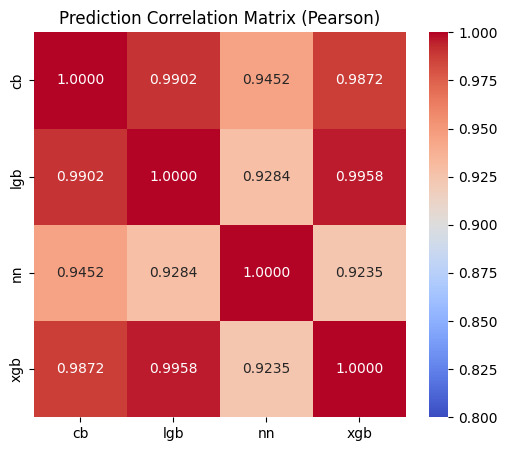

In [7]:
# Plot Pearson correlation between predictions
plt.figure(figsize=(6, 5))
sns.heatmap(oof_df.corr(method='pearson'), annot=True, cmap='coolwarm', fmt='.4f', vmin=0.8, vmax=1.0)
plt.title('Prediction Correlation Matrix (Pearson)')
plt.show()

## 4. Simple Probability Average & Rank Average

In [8]:
avg_oof = X_oof.mean(axis=1)
avg_score = roc_auc_score(y, avg_oof)
print(f"Simple Probability Average OOF ROC AUC: {avg_score:.6f}")

Simple Probability Average OOF ROC AUC: 0.962172


In [9]:
# Convert predictions to percentile ranks before averaging to mitigate calibration offsets
rank_oof = np.zeros_like(X_oof)
for i in range(X_oof.shape[1]):
    rank_oof[:, i] = rankdata(X_oof[:, i]) / len(y)
    
rank_avg_oof = rank_oof.mean(axis=1)
rank_avg_score = roc_auc_score(y, rank_avg_oof)
print(f"Rank Average OOF ROC AUC: {rank_avg_score:.6f}")

Rank Average OOF ROC AUC: 0.961634


## 5. Optimized Weighted Probability Average

Finds the weight mixture that directly maximizes OOF ROC AUC score.

In [10]:
def loss_func(weights):
    w = weights / np.sum(weights)
    blend = np.dot(X_oof, w)
    return -roc_auc_score(y, blend)

# Nelder-Mead optimization starting with equal weights
res = minimize(loss_func, [1/len(model_names)]*len(model_names), method='Nelder-Mead', bounds=[(0, 1)]*len(model_names))
opt_weights = res.x / np.sum(res.x)
opt_blend_oof = np.dot(X_oof, opt_weights)
opt_score = roc_auc_score(y, opt_blend_oof)

print(f"Optimized weights:")
for name, weight in zip(model_names, opt_weights):
    print(f"  {name}: {weight:.4f}")
print(f"Optimized Weighted Average OOF ROC AUC: {opt_score:.6f}")

Optimized weights:
  cb: 0.0000
  lgb: 0.5470
  nn: 0.0000
  xgb: 0.4530
Optimized Weighted Average OOF ROC AUC: 0.964572


## 6. RidgeCV Stacking

We train a meta-regressor (`RidgeCV`) using out-of-fold cross-validation to combine probabilities optimally while regularizing coefficients.

In [11]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
stack_oof = np.zeros(len(y))

for train_idx, val_idx in skf.split(X_oof, y):
    meta_model = RidgeCV(alphas=np.logspace(-3, 3, 15))
    meta_model.fit(X_oof[train_idx], y[train_idx])
    stack_oof[val_idx] = meta_model.predict(X_oof[val_idx])

stack_score = roc_auc_score(y, stack_oof)
print(f"RidgeCV Stacking OOF ROC AUC: {stack_score:.6f}")

RidgeCV Stacking OOF ROC AUC: 0.964630


## 7. Model Performance Comparison

In [12]:
comparison = {
    'Model/Strategy': model_names + [
        'Simple Average',
        'Rank Average',
        'Optimized Weighted Average',
        'RidgeCV Stacking'
    ],
    'OOF ROC AUC': [
        single_scores[name] for name in model_names
    ] + [
        avg_score,
        rank_avg_score,
        opt_score,
        stack_score
    ]
}

comp_df = pd.DataFrame(comparison).sort_values('OOF ROC AUC', ascending=False)
comp_df

,Model/Strategy,OOF ROC AUC
7,RidgeCV Stacking,0.965
6,Optimized Weighted Average,0.965
1,lgb,0.964
3,xgb,0.964
4,Simple Average,0.962
5,Rank Average,0.962
0,cb,0.960
2,nn,0.940


## 8. Final Meta-Model Training & Submission

Fits the meta-model on all OOF predictions to learn the final coefficients, then applies them to test predictions.

In [13]:
final_meta = RidgeCV(alphas=np.logspace(-3, 3, 15))
final_meta.fit(X_oof, y)

print("Final Stacking Coefficients:")
for name, coef in zip(model_names, final_meta.coef_):
    print(f"  {name}: {coef:.4f}")
print(f"Intercept: {final_meta.intercept_:.4f}")
print(f"Selected Regularization Alpha: {final_meta.alpha_:.4f}")

Final Stacking Coefficients:
  cb: -0.1960
  lgb: 0.7550
  nn: -0.0352
  xgb: 0.4814
Intercept: -0.0042
Selected Regularization Alpha: 1.0000


In [14]:
# Apply meta-model to test predictions and clip to [0.0, 1.0] range
final_test_preds = final_meta.predict(X_test)
final_test_preds = np.clip(final_test_preds, 0.0, 1.0)

# Apply meta-model to OOF predictions for visualization
final_oof_preds = final_meta.predict(X_oof)
final_oof_preds = np.clip(final_oof_preds, 0.0, 1.0)

In [15]:
submission_df['addicted_label'] = final_test_preds
submission_df.to_csv('submission.csv', index=False)
print("Saved stacked submission.csv successfully!")

Saved stacked submission.csv successfully!


## 9. Final Ensemble Visualization

<Figure size 800x600 with 0 Axes>

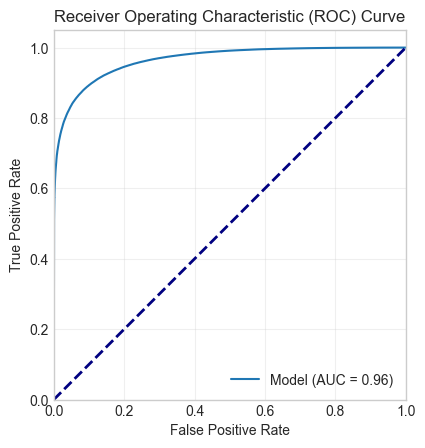

In [16]:
mviz = ModelVisualizer(model_name='RidgeCV Stacking')
mviz.plot_roc_curve(y_true=y, y_score=final_oof_preds)

Confusion matrix, without normalization


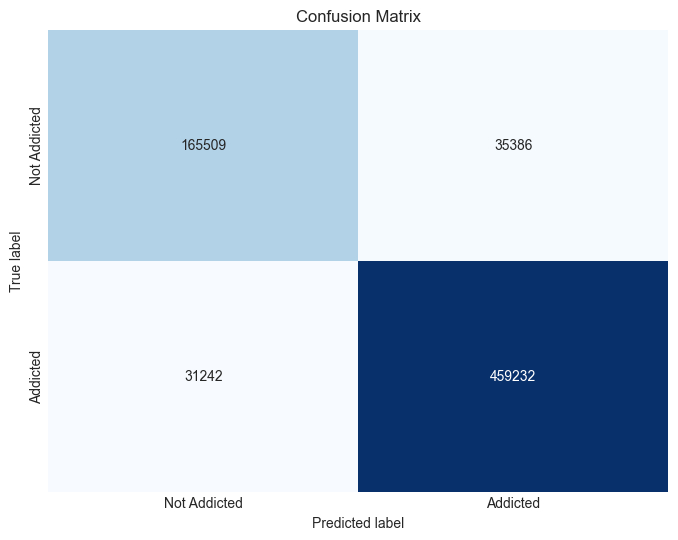

In [17]:
final_oof_class = (final_oof_preds > 0.5).astype(int)
mviz.plot_confusion_matrix(
    y_true=y,
    y_pred=final_oof_class,
    classes=['Not Addicted', 'Addicted']
)

In [18]:
# Save ensemble predictions to cache folder
# Format ensemble probabilities for setup.save_probabilities expects column 0 = 1 - p, column 1 = p
final_oof_probs = np.column_stack([1.0 - final_oof_preds, final_oof_preds])
final_test_probs = np.column_stack([1.0 - final_test_preds, final_test_preds])

setup.save_probabilities(
    'ensemble',
    final_oof_probs,
    train_ids,
    y_true,  # Pass the pandas Series to match save_probabilities expectations
    np.ones(len(y_true), dtype=bool),
    final_test_probs,
    test_ids
)

Saved for ensembling:
 - predictions/ensemble_oof_probs.csv
 - predictions/ensemble_test_probs.csv
